# 第32课 · 给声音标上时刻 — 用 np.arange 造出 16kHz 时间轴（time axis）

**今日目标**：写出 `time_axis(duration, sample_rate)`，把 duration / sample_rate / N 与时间轴数组钉死。

> **与 L02 的关系**：采样与 `N = duration × sr` 你在 L02 已手算过。本课不是重讲物理，而是把同一直觉**工程化成可复用函数**，并固定语音惯例 **sr = 16000 Hz**（ASR 常见；CD 是 44100）。

**核心关系**：
- `N = round(duration × sample_rate)` — 采样点总数
- `t = np.arange(N) / sample_rate` — 每个点对应的时刻（秒）

Audio Core 读任何信号的第一步都是建立这条时间轴；后续 STFT / Mel 用同样的点序号换算时间。

看到 ✏️ 的格子就是你要填代码的地方，按 `Shift+Enter` 逐格运行。

← **上一课**　[L31 · 概率分布可视化](../4_probability/L31_visual_probability.ipynb)

> 上节课学习了 **概率分布可视化**：PDF、CDF 与交叉熵损失曲面动态演示。  
> 本课将探讨 **NumPy 信号基础**。

## 回顾 L03 · 谱图直觉 → 今天要造时间轴

L03 让你先看过谱图：横轴是时间，纵轴是频率，颜色亮度是能量。

从 L32 开始，我们倒过来把这张图的材料一步步造出来：

```text
L32 时间轴 t
  → L33 正弦波 x(t)
  → L36 加窗
  → L39 FFT
  → L43-L45 STFT / 声谱图
```

所以本课只做一件小而关键的事：回答「第 n 个采样点在第几秒？」

```text
t[n] = n / sample_rate
```

这不是小细节，而是所有频域分析的坐标系统。


## 预热：从物理角度理解采样率

想象用高速摄像机录视频。如果你用 60 帧/秒的摄像机录 1 秒的视频，就得到 60 张图片。为什么？因为"每秒 60 帧"意味着每秒拍 60 张，所以 1 秒 = 60 张。

**采样率的逻辑完全一样**。采样率 16000 Hz（赫兹）= 每秒采 16000 个点。录 1 秒，就得 16000 个数字。录 0.5 秒，就得 8000 个数字。

**因次分析**（高中物理的做法）：
- 采样率单位：点/秒（每秒多少个点）
- 时长单位：秒
- 点数 = （点/秒）×（秒）= 点 ✓

**换算时刻的逻辑**也很直白：  
- 点编号（第几个）：0, 1, 2, ...（无单位）
- 采样率：16000 点/秒
- 第 n 个点的时刻 = n ÷（16000 点/秒）= n/16000 秒 ✓

这就是为什么 `t = np.arange(N) / sample_rate` 能直接把点序号变成秒数。除法的单位运算会自动消掉"点"，留下"秒"。

In [1]:
# Aurora matplotlib bootstrap
from pathlib import Path
import sys

_root = None
_cwd = Path.cwd().resolve()
for _candidate in (_cwd, *_cwd.parents):
    if (_candidate / '_matplotlib_bootstrap.py').exists():
        _root = _candidate
        break
if _root is None:
    _notebooks_dir = _cwd / 'notebooks'
    if _notebooks_dir.exists():
        for _found in _notebooks_dir.rglob('_matplotlib_bootstrap.py'):
            _root = _found.parent
            break
if _root is not None and str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

from _matplotlib_bootstrap import apply as _aurora_mpl_apply
_aurora_mpl_apply()


✅ 先记住谱图的横轴是时间；L32 的任务就是造出这条 time axis


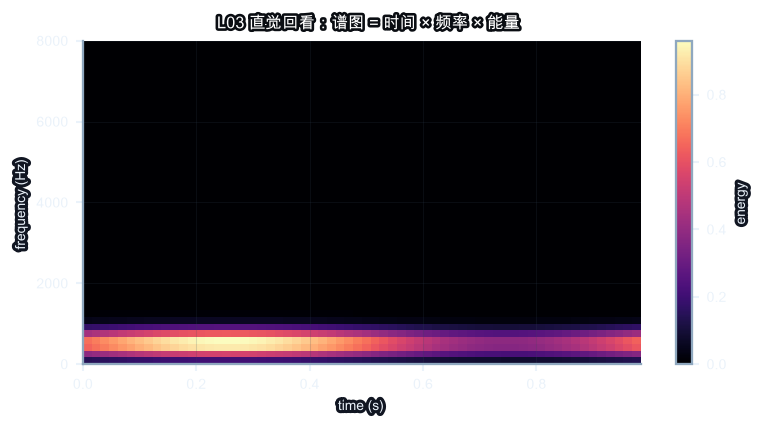

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# 这不是正式谱图计算，只是把 L03 的三根轴轻量拉回来。
time = np.linspace(0.0, 1.0, 64, endpoint=False)
freq = np.linspace(0.0, 8000.0, 48)
energy = np.exp(-((freq[:, None] - 440.0) / 350.0) ** 2) * (0.7 + 0.3 * np.sin(2 * np.pi * time))[None, :]

plt.figure(figsize=(6, 2.8))
plt.imshow(
    energy,
    origin="lower",
    aspect="auto",
    extent=[time[0], time[-1], freq[0], freq[-1]],
    cmap="magma",
)
plt.xlabel("time (s)")
plt.ylabel("frequency (Hz)")
plt.title("L03 直觉回看：谱图 = 时间 × 频率 × 能量")
plt.colorbar(label="energy")
plt.show()

assert energy.shape == (len(freq), len(time))
print("✅ 先记住谱图的横轴是时间；L32 的任务就是造出这条 time axis")


## 本课剧情：声音是一串数字——给它分配时间坐标

有没有想过，一段录音在计算机里长什么样？

不是一张图、不是一段文字——是**一列数字**，每个数字代表麦克风在某一瞬间测到的气压值。以 16000 Hz 采样率（sample rate，sr）录制 1 秒钟的声音，就产生 16000 个数字。

问题是：这 16000 个数字"发生在"哪个时刻？

答案就是今天要实现的时间轴：

```
t = np.arange(N) / sample_rate
```

这行代码做了两步：
1. `np.arange(N)` → 生成编号 `[0, 1, 2, ..., 15999]`（点序号）
2. `/ sample_rate` → 换算为秒 `[0.0, 0.0000625, ..., 0.99994]`

### 为什么是 arange 而不是 linspace？

乍一看，`np.linspace(0, duration, N)` 似乎更直接——"从 0 到 duration 均匀分 N 个点"。但有个细节：
- `np.arange(N) / sr` 生成的是**精确的分数** `0/sr, 1/sr, 2/sr, ..., (N-1)/sr`，完全无误差
- `np.linspace(0, duration, N)` 在端点间均匀分，中间的值是浮点数近似，可能累积微小误差

在信号处理中，我们需要点序号与时刻的对应关系**精确**——否则后面（比如 FFT 或谱图计算）基于点序号做的频率对齐会出问题。所以 arange 的做法更稳妥。

本节任务：实现 `time_axis(duration, sample_rate)` 并用断言验证它。

### 写 `time_axis` 前明确三件事

- **输入**：`duration`（总时长，秒）、`sample_rate`（每秒采样点数，Hz）
- **关键步骤**：先算 `N = round(duration * sample_rate)`，再算 `np.arange(N) / sample_rate`
- **返回**：长度为 `N` 的一维 float 数组，每个元素是对应采样点的时刻（秒）

## 实验入口：把声音拆成可观察的数组

用短时长（0.1 s）和低采样率（16 Hz）运行第一个例子，直接打印 `N` 和 `t`，观察点数如何随 `duration × sample_rate` 变化，以及 `t[-1]` 总是比 `duration` 短一个采样间隔。

## 1. 导入 numpy

`import numpy as np` = 把数值计算库 numpy 拿进来，并起个简称 `np`。以后 `np.xxx` 就是在用它。

你可以把 numpy 想成"会整批处理数字的工具箱"。普通 Python 适合一个一个处理值，numpy 适合一次处理一整串值。我们今天要生成的是"序列"，所以它正好派上用场。运行下面这格：

In [3]:
import numpy as np
print('numpy 已就绪:', np.__version__)

numpy 已就绪: 2.5.0


## 动手观察：序列怎样一步步变成信号

修改 `sample_rate` 或 `duration`，观察 `n`（整数序号数组）和 `t`（时间数组）的长度如何同步变化。重点确认：`t[-1]` 始终等于 `(N-1) / sample_rate`，而不是 `duration` 本身。

## 预热 2：圆周运动与正弦波的关系

你一定疑惑过，为什么音频公式中总出现 **2π**？

想象一个点在圆周上匀速转圈。每转一圈，角度变化 360° 或 `2π` 弧度（2π ≈ 6.28）。如果每秒转 f 圈，那 t 秒后转过的角度就是 `2π·f·t` 弧度。

而圆周上一个点的竖直坐标（从中心到这一点的竖直位移）正好是 **sin(角度)**。随着转圈，这个竖直坐标在 -1 到 1 之间来回摆动，形成正弦波。

```text
圆周上的角度 = 2π·f·t（每秒转f圈，转t秒）
    ↓
正弦波 = sin(2π·f·t)（圆周上一点的竖直坐标）
```

所以 `sin(2π·f·t)` 是把"频率（每秒转几圈）"和"时间"转换成"角度"，再取正弦值。

这就是 2π 存在的原因。它不是魔法，而是几何。

In [4]:
import numpy as np

sample_rate = 8
duration = 1.0
freq = 2.0
N = round(duration * sample_rate)
n = np.arange(N)
t = n / sample_rate
angle = 2 * np.pi * freq * t
wave = np.sin(angle)

print('N =', N)
print('采样点编号 n =', n)
print('时间轴 t =', np.round(t, 3))
print('角度 angle =', np.round(angle, 3))
print('sin(angle) =', np.round(wave, 3))


N = 8
采样点编号 n = [0 1 2 3 4 5 6 7]
时间轴 t = [0.    0.125 0.25  0.375 0.5   0.625 0.75  0.875]
角度 angle = [ 0.     1.571  3.142  4.712  6.283  7.854  9.425 10.996]
sin(angle) = [ 0.  1.  0. -1. -0.  1.  0. -1.]


## 代码实验：遍历不同时长和采样率

验证 `N = duration × sample_rate` 在不同参数组合下严格成立，同时确认 `t[-1]` 始终比总时长短一个采样间隔 `1 / sample_rate`。

In [5]:
import numpy as np

for duration in [0.25, 0.5, 1.0]:
    for sample_rate in [4, 8]:
        N = round(duration * sample_rate)
        t = np.arange(N) / sample_rate
        print(f'duration={duration}, sample_rate={sample_rate} -> N={N}, t={np.round(t, 3)}')


duration=0.25, sample_rate=4 -> N=1, t=[0.]
duration=0.25, sample_rate=8 -> N=2, t=[0.    0.125]
duration=0.5, sample_rate=4 -> N=2, t=[0.   0.25]
duration=0.5, sample_rate=8 -> N=4, t=[0.    0.125 0.25  0.375]
duration=1.0, sample_rate=4 -> N=4, t=[0.   0.25 0.5  0.75]
duration=1.0, sample_rate=8 -> N=8, t=[0.    0.125 0.25  0.375 0.5   0.625 0.75  0.875]


## 2. 先认识 `np.arange`

`np.arange(n)` 生成一串整数 `0, 1, 2, ..., n-1`。这一步非常关键，因为它先帮我们搭出“第几个采样点”的骨架。

可以把它看成：先拿到一排座位号，再决定每个座位对应的具体时刻。对数组做 `/ 数字` 会**每个元素都除**，所以我们能把整数序号直接变成时间。先玩一下：


In [6]:
print(np.arange(5))          # [0 1 2 3 4]
print(np.arange(5) / 10)     # [0.  0.1 0.2 0.3 0.4]  每个都除以 10

[0 1 2 3 4]
[0.  0.1 0.2 0.3 0.4]


## 3. ✏️ 实现 `time_axis(duration, sample_rate)`

### 为什么 `t[-1] < duration`？从麦克风的角度理解采样

假设你用麦克风录 1 秒的声音，采样率 4 Hz（为了便于手算，我们用很低的采样率）。

- 采样的 4 个点分别在：第 0 秒、第 0.25 秒、第 0.5 秒、第 0.75 秒  
- **没有第 1.0 秒的点**，因为采样在 1 秒时就停了

为什么？因为 N 个采样点的编号是 `0 到 N-1`（共 N 个），不是 `0 到 N`。这是计数的基本规则——列表有 4 个元素，下标就是 0、1、2、3。

```
点编号      时刻
  0       0/4 = 0.00 s
  1       1/4 = 0.25 s
  2       2/4 = 0.50 s
  3       3/4 = 0.75 s  ← 最后一点，比 duration=1.0 短
```

如果强行在 1.0 秒加第 5 个点（编号 4），就变成了 5 个采样点，不符合"1 秒 4 Hz = 4 个点"的定义。

**CD 音频的例子**（sr=44100, duration=1.0）：  
- N = 44100 个点，编号 0 到 44099  
- 最后一点 = 44099 / 44100 ≈ 0.99998 秒，比 1.0 秒少了 1/44100 ≈ 0.0000227 秒

### round() 为什么必要？浮点数乘法的陷阱

虽然我们期望 `duration × sample_rate` 总是整数，但计算机里的浮点数有舍入误差。比如：

```python
duration = 0.1
sample_rate = 22050
N_no_round = duration * sample_rate  # 可能是 2204.9999999999998
np.arange(N_no_round)  # ❌ 报错：arange 只接受整数
```

`round()` 把浮点数舍入到最近的整数，避免这个问题：

```python
N = round(duration * sample_rate)  # 2205 ✓
np.arange(N)  # ✓ 工作正常
```

所以 `round()` 不是装饰品，而是必需的防守。

### 三步实现路线

| 步骤 | 代码 | 含义 |
|---|---|---|
| 1 | `N = round(duration * sample_rate)` | 总采样点数（用 round 避免浮点误差） |
| 2 | `n = np.arange(N)` | 整数点编号 `[0, 1, ..., N-1]` |
| 3 | `t = n / sample_rate` | 每点对应时刻（秒），第 k 点 = `k/sr` |

**参考输入输出**：`duration=0.5, sample_rate=8` → N=4，t=[0, 0.125, 0.25, 0.375]（都是精确的分数）

In [7]:
def time_axis(duration, sample_rate):
    """
    返回长度为 N = round(duration * sample_rate) 的一维 float 数组，
    每个元素是对应采样点的时刻（秒）。
    """
    # TODO: 参照上方推理路线实现此函数
    # 提示：先算 N，再生成整数编号，再除以 sample_rate
    raise NotImplementedError("请参照上方推理路线实现此函数")

## 4. 运行检查（自动判卷）

### 浮点精度为什么重要？

电脑用的是二进制浮点数，某些十进制小数无法精确表示。比如 `0.1` 实际上存的是 `0.1000000000000000055...`。当我们做很多乘除运算时，这些微小误差会累积。

检查时，我们不能说"必须精确相等"，而是说"足够接近就算对"。标准是用**阈值**——比如 `< 1e-12` 意思是"误差小于一万亿分之一"。在音频信号处理中，这个精度已经远超麦克风和扬声器的实际分辨率，足以认为是"正确"。

### 检验代码解读

这一步不是"机器替你思考"，而是帮你快速确认三件事：长度对不对、前几个值对不对、最后一个值落在哪。

实现对了，下面会打印 ✅；错了会报错告诉你哪不对。建议你先看报错信息，再回去对照上面的变量关系，而不是只盯着答案本身。

In [ ]:
sr = 16000
t = time_axis(1.0, sr)
print('采样点个数  :', t.shape[0], ' (期望', sr, ')')
print('前 5 个时刻 :', t[:5])
print('最后 1 个时刻:', round(float(t[-1]), 6), '秒')

assert t.shape[0] == sr, '采样点个数应等于采样率'
assert abs(t[1] - t[0] - 1/sr) < 1e-12, '相邻时刻间隔应为 1/sr'
print('\n✅ 通过：采样率与时间轴关系检查完成。')


## 5. 逐行回顾（看懂了就过）

- `np.arange(duration * sample_rate)` → 先得到一串“点编号”，比如 `0,1,2,...,15999`
- `/ sample_rate` → 再把编号换算成秒，所以每个元素都像“这一点在时间轴上的位置”
- `t.shape[0]` = 数组长度；`t[:5]` = 前 5 个；`t[-1]` = 最后一个，这些都是看序列是否符合预期的基本方法
- `assert 条件, '信息'` = 自动判卷：真则放行，假则报错
- `abs(...) < 1e-12`：电脑算小数有微小误差，所以判断“足够接近”而不是“严格相等”

你可以把这整节课记成一句话：**先造整数序列，再把整数序列映射成时间序列。** 这就是很多音频、信号、图像代码的基本思路。

**🎉 完成后**：保存 notebook（`Ctrl+S`），回终端 `git add notebooks/5_audio_dsp/L32_numpy_signals.ipynb && git commit -m 'learn: L32 numpy_signals'  # 'learn: L32 numpy_signals'`


## 🎨 图示：信号 = 一串采样点

In [ ]:
try:
    from aurora.audio import sine
    import aurora.aviz as aviz; aviz.style()
    aviz.waveform(sine(5.0, duration=1.0, sample_rate=64), stem=True,
                  title='5 Hz 正弦 @ 64 采样点')
except ImportError as e:
    print(f'⚠️  Aurora 未安装，跳过图示（{e}）。')
    print('提示：在终端运行 `pip install -e /path/to/AURORA[notebooks]` 后重新执行此格。')
    print('图示展示 5 Hz 正弦波在 64 Hz 采样率下的 64 个采样点，每点对应时间轴上的一刻。')

In [ ]:
duration_options = [0.125, 0.25, 0.5]
sample_rates = [8, 16]

for duration in duration_options:
    for sr in sample_rates:
        N = round(duration * sr)
        t = np.arange(N) / sr
        verdict = '空序列' if len(t) == 0 else f'最后一点={t[-1]:.4f}s'
        print(f'duration={duration:>5}, sr={sr:>2} -> N={N:>2}, {verdict}')


## 参数实验：采样率翻倍的效果

把 `sample_rate` 从 `8` 改到 `16`（采样率翻倍），对比 `duration=0.5` 下的结果：

| sample_rate | N | t[-1] |
|---|---|---|
| 8 | 4 | 0.375 s |
| 16 | 8 | 0.4375 s |

N 和 t 数组长度都翻倍，但两个 `t[-1]` 都接近 `duration=0.5` 而没有超出——更高采样率用更多点覆盖同样时长，而不是覆盖更长时段。每次只改一个参数，先预测 N 和 `t[-1]` 的值，再运行验证。

In [ ]:
duration_options = [0.125, 0.25, 0.5]
sample_rates = [8, 16]

for duration in duration_options:
    for sr in sample_rates:
        N = round(duration * sr)
        t = np.arange(N) / sr
        last = '无最后点' if len(t) == 0 else f'{t[-1]:.4f}s'
        print(f'duration={duration:>5}, sr={sr:>2} -> N={N:>2}, last={last}')


## 本课收束

现在能用 `time_axis(duration, sample_rate)` 生成任意时长的时间轴数组，并通过 assert 验证长度和端点值。这个函数对应 Aurora Audio Core 中所有信号读取路径的第一步——在进入任何频域分析之前都需要先建立这个坐标系。L33 会把今天的 `t` 代入 `np.sin(2 * np.pi * freq * t)`，生成实际的正弦波音频信号。

下一课（L33）从最简单的信号——纯音正弦波——出发，用 `np.sin` 生成采样序列，测量频率与周期的关系。

In [ ]:
# 小检查：从短序列开始，确认每一步输出
import numpy as np

sample_rate = 8
duration = 1.0
freq = 1.0
N = round(duration * sample_rate)
n = np.arange(N)
t = n / sample_rate
angle = 2 * np.pi * freq * t
x = np.sin(angle)

print('1) N 应该是多少？', N)
print('2) n 是采样点编号：', n)
print('3) t 是每个点的秒数：', np.round(t, 3))
print('4) angle 是每个点在圆上的角度：', np.round(angle, 3))
print('5) x 是最终波形：', np.round(x, 3))


---
⬇️ **通关检验**：收束小结已读；请完成下方白板挑战后再勾选自评。


## ✏️ 白板挑战：时间轴手算（目标 8 分钟）

盖上屏幕，纸上作答：

**问 1**：`duration=0.5, sample_rate=22050`  
- N = ?（总采样点数）  
- t[0] = ?  
- t[-1] = ?（精确分数和近似小数）  
- t[-1] 比 `duration=0.5` 短多少秒？

**问 2**：`t[1000]` 当 `sample_rate=22050` 时 = ?  
（公式：`t[k] = k / sample_rate`）

**问 3**：有了时间轴 `t`，写出 440 Hz 正弦波的公式（一行 NumPy）

**问 4**：为什么要用 `np.arange(N) / sr` 而不是 `np.linspace(0, duration, N)`？  
（提示：arange 生成精确的分数 k/sr，linspace 用浮点近似——比较两者的 t[1000] 会发现不同）

推导完成后运行下面格对答案。

In [ ]:
# ✏️ 对答案格
import numpy as np

# 问1：duration=0.5, sr=22050
sr = 22050
dur = 0.5
N = round(dur * sr)
assert N == 11025, f"N 应=11025，得到 {N}"
t = np.arange(N) / sr
assert t[0] == 0.0
assert np.isclose(t[-1], 11024 / 22050, atol=1e-15)
gap = dur - t[-1]
assert np.isclose(gap, 1 / sr, atol=1e-15)
print(f"Q1 ✅  N={N}，t[0]={t[0]}，t[-1]={t[-1]:.8f}（≈{t[-1]:.5f}）")
print(f"      比 duration={dur} 短 {gap:.8f}s = 1/sr")

# 问2：t[1000] = 1000/22050
t1000 = t[1000]
assert np.isclose(t1000, 1000 / 22050, atol=1e-15)
print(f"Q2 ✅  t[1000] = 1000/22050 = {t1000:.8f}s ≈ {t1000*1000:.4f}ms")

# 问3：440 Hz 正弦波 = sin(2π·440·t)
x_440 = np.sin(2 * np.pi * 440 * t)
assert x_440.shape == (N,) and np.isclose(x_440[0], 0.0, atol=1e-15)
# 离散采样点未必正好落在连续峰值上，只要最接近的采样值接近 1 即可
assert abs(np.max(x_440) - 1.0) < 1e-3
print(f"Q3 ✅  x = np.sin(2π·440·t)，shape={x_440.shape}，峰值={np.max(x_440):.6f}")

# 问4：arange vs linspace 精度对比（不涉及 FFT，只看数值差异）
t_linspace = np.linspace(0, dur, N, endpoint=False)
t_arange = np.arange(N) / sr
diff_at_1000 = abs(t_arange[1000] - t_linspace[1000])
max_diff = np.max(np.abs(t_arange - t_linspace))
print(f"Q4 ✅  arange vs linspace 对比：")
print(f"      t_arange[1000]  = {t_arange[1000]:.15f}")
print(f"      t_linspace[1000]= {t_linspace[1000]:.15f}")
print(f"      误差 = {diff_at_1000:.2e}")
print(f"      整数组 arange/sr 是精确分数，linspace 是浮点近似，精度差异在大规模计算中会累积")
print("\n🎉 时间轴白板挑战通过！np.arange(N)/sr 是音频信号的基础坐标。")

In [ ]:
# ✏️ 本课自评
l32_review = {
    "N_formula":             None,  # 记住 N=round(duration*sample_rate)？True/False
    "time_axis_implemented": None,  # time_axis 实现并通过断言？True/False
    "t_last_lt_duration":    None,  # 理解 t[-1] < duration（少一个采样间隔）？True/False
    "arange_vs_linspace":    None,  # 知道 arange/sr 比 linspace 更精确？True/False
    "whiteboard_passed":     None,  # 白板挑战纸上推导完成？True/False
}

unfilled = [k for k, v in l32_review.items() if v is None]
assert not unfilled, f'还未填写：{unfilled}'
weak = [k for k, v in l32_review.items() if v is False]
if weak:
    print(f'⚠️  需要加强：{weak}')
else:
    print('✅ L32 全部通关！进入 L33：正弦波生成')


---

→ **下一课**　[L33 · 正弦波生成](L33_sine_wave.ipynb)

> 下节课将学习 **正弦波生成**：x[n]=A·sin(2πfn/sr)，亲手实现并对齐 aurora.audio.sine。